# Aula 01 — Pandas e Matplotlib: Da Base de Dados ao Gráfico

Bem-vindo(a) à primeira aula de Visualização de Dados!

Aqui você vai aprender, passo a passo, a trabalhar com dados reais usando duas bibliotecas muito poderosas do Python:

- **pandas** — para carregar, explorar e transformar dados (pense nela como o Excel do Python)
- **matplotlib** — para criar gráficos e visualizações

A base de dados que usamos é fictícia, de Recursos Humanos, com informações de 1.000 funcionários de uma empresa. Vamos explorar salários, departamentos, idades e muito mais.

Não se preocupe se parecer muita coisa de uma vez — vamos devagar, explicando cada passo.

## Célula 1 — Importando as bibliotecas e carregando os dados

Antes de qualquer coisa, precisamos **importar as ferramentas** que vamos usar. No Python, essas ferramentas se chamam **bibliotecas**.

```python
import pandas as pd          # ferramenta de dados
import matplotlib.pyplot as plt  # ferramenta de gráficos
```

- O `as pd` cria um apelido: em vez de digitar `pandas` toda vez, usamos só `pd`.
- O mesmo vale para `plt` — muito mais rápido de escrever.

Depois definimos a **URL** onde está o arquivo Excel (hospedado no GitHub) e usamos `pd.read_excel(URL)` para carregar tudo em uma variável chamada `df` (abreviação de *DataFrame* — a "planilha" do pandas).

Por último, convertemos a coluna `Data_Admissao` para o tipo **data** com `pd.to_datetime()`. Sem essa conversão, o pandas trata a data como texto e não consegue fazer cálculos com ela.

> O parâmetro `errors="coerce"` diz ao pandas: "se um valor não puder ser convertido em data, coloque nulo no lugar em vez de travar com erro".

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/aulas/semana_04/bases/base_rh.xlsx"
)

df = pd.read_excel(URL)

df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado: 1000 linhas x 10 colunas


## Célula 2 — Primeira olhada nos dados

Quando trabalhamos com bases grandes, **nunca** imprimimos a tabela inteira — seriam mil linhas na tela, impossível de ler.

O método `df.head()` mostra apenas as **5 primeiras linhas** — o suficiente para entender a estrutura: quais colunas existem e que tipo de valores elas têm.

> O `# print(df)` está **comentado** (precedido por `#`). O símbolo `#` "desliga" uma linha de código sem apagá-la. Deixamos assim para mostrar que a opção existe, mas ela não é prática para bases com muitas linhas.

In [19]:
# print(df)               # Mostra o DataFrame completo
print(df.head())       # Mostra as primeiras 5 linhas


   ID_Funcionario                 Nome Departamento        Cargo   Salario  \
0               1          Julia Nunes    Logística  Coordenador   9088.34   
1               2   Sr. Gustavo Duarte           TI      Gerente   8155.98   
2               3  Srta. Mariana Cunha           RH  Coordenador  14027.93   
3               4   Ana Sophia da Cruz     Produção      Técnico   6647.97   
4               5    Dr. Nicolas Pinto     Produção      Gerente   8730.19   

  Data_Admissao Genero  Idade Estado_Civil   Status  
0    2024-08-13      F     43     Solteiro  Inativo  
1    2017-04-29      F     59     Solteiro  Inativo  
2    2024-12-11      F     27   Divorciado    Ativo  
3    2019-06-16      M     50       Casado  Inativo  
4    2019-03-29      F     62       Casado  Inativo  


## Célula 3 — Explorando a estrutura do dataset

Todo analista tem um "checklist" que roda toda vez que pega uma base nova. Aqui está o nosso:

| Método | O que mostra |
|---|---|
| `head(10)` | As 10 primeiras linhas |
| `tail()` | As 5 últimas linhas |
| `columns` | Nome de todas as colunas |
| `info()` | Tipo de dado de cada coluna e se há valores nulos |
| `describe()` | Estatísticas das colunas numéricas (média, mín, máx...) |

O `info()` é especialmente importante: se uma coluna de salários foi lida como *texto* em vez de *número*, não conseguimos calcular a média — e o `info()` nos avisa sobre isso antes de qualquer erro.

In [20]:
# print(df.head(10))   # 10 primeiras linhas
# print(df.tail())     # últimas 5 linhas
# print(df.columns)    # nomes das colunas
# print(df.info())     # estrutura da base
print(df.describe()) # estatísticas numéricas



       ID_Funcionario       Salario               Data_Admissao        Idade
count     1000.000000   1000.000000                        1000  1000.000000
mean       500.500000   8579.951780  2020-11-15 13:43:40.800000    41.399000
min          1.000000   2000.710000         2015-09-25 00:00:00    18.000000
25%        250.750000   5564.545000         2018-05-13 06:00:00    30.000000
50%        500.500000   8571.135000         2020-12-25 00:00:00    41.000000
75%        750.250000  11554.630000         2023-05-15 12:00:00    53.000000
max       1000.000000  14954.510000         2025-09-22 00:00:00    65.000000
std        288.819436   3657.365307                         NaN    13.665817


## Célula 4 — Series: o que acontece quando selecionamos uma coluna

No pandas existem dois tipos principais de estrutura:

- **DataFrame** = tabela completa (2 dimensões: linhas + colunas)
- **Series** = uma única coluna (1 dimensão: só linhas)

Quando escrevemos `df["Salario"]`, o resultado é uma **Series**.

O atributo `shape` confirma isso:
- Series: `(1000,)` → só tem 1 dimensão
- DataFrame: `(1000, 2)` → tem 2 dimensões

O `dtype` mostra o tipo de dado armazenado: `float64`, `int64`, `object` (texto), `category`, etc.

Saber se você está com uma Series ou um DataFrame importa porque alguns métodos só existem em um dos dois!

In [21]:
# Uma coluna → Series
salarios = df["Salario"]
print(f"Tipo  : {type(salarios)}")
print(f"shape : {salarios.shape}")   # (1000,) — 1 dimensão
print(f"dtype : {salarios.dtype}")
print(salarios.head(4))

print("\n" + "─"*38)

Tipo  : <class 'pandas.Series'>
shape : (1000,)
dtype : float64
0     9088.34
1     8155.98
2    14027.93
3     6647.97
Name: Salario, dtype: float64

──────────────────────────────────────


## Célula 5 — DataFrame: selecionando duas ou mais colunas

Para selecionar **várias colunas ao mesmo tempo**, passamos uma **lista** de nomes dentro dos colchetes. Repare nos colchetes duplos:

```python
df[["Nome", "Salario"]]   # duplo: retorna DataFrame
df["Salario"]             # simples: retorna Series
```

Isso pode parecer estranho no começo, mas faz sentido: o colchete externo é o operador de seleção do DataFrame, e o interno é a lista Python com os nomes das colunas.

O `shape` agora mostra `(1000, 2)` — 1.000 linhas e 2 colunas: é um DataFrame de verdade.

In [22]:
# Duas colunas → DataFrame
sub = df[["Nome", "Salario"]]
print(f"\nTipo  : {type(sub)}")
print(f"shape : {sub.shape}")         # (1000, 2) — 2 dimensões
print(sub.head(3))

print("\n" + "─"*38)


Tipo  : <class 'pandas.DataFrame'>
shape : (1000, 2)
                  Nome   Salario
0          Julia Nunes   9088.34
1   Sr. Gustavo Duarte   8155.98
2  Srta. Mariana Cunha  14027.93

──────────────────────────────────────


## Célula 6 — Estatísticas básicas: média, mediana, mínimo e máximo

Com a Series `salarios` em mãos, calculamos as estatísticas mais comuns:

| Método | O que calcula |
|---|---|
| `mean()` | Média aritmética |
| `median()` | Mediana (valor do meio quando ordenamos todos) |
| `min()` | Menor valor |
| `max()` | Maior valor |

> **Média vs Mediana:** se um diretor ganha R$ 500.000, ele puxa a média pra cima e distorce a realidade da maioria. A mediana é mais robusta a esse tipo de distorção — por isso sempre vale comparar as duas.

O `:,.2f` dentro do f-string formata o número com separador de milhar (`,`) e duas casas decimais (`.2f`). Exemplo: `12500.50` vira `12,500.50`.

In [23]:
# Estatísticas — só funcionam direto na Series
print(f"\nMédia   : R$ {salarios.mean():,.2f}")
print(f"Mediana : R$ {salarios.median():,.2f}")
print(f"Mínimo  : R$ {salarios.min():,.2f}")
print(f"Máximo  : R$ {salarios.max():,.2f}")


Média   : R$ 8,579.95
Mediana : R$ 8,571.13
Mínimo  : R$ 2,000.71
Máximo  : R$ 14,954.51


## Célula 7 — Histograma: como os salários estão distribuídos

Um **histograma** divide os valores em faixas e mostra quantos registros caem em cada faixa. É o gráfico ideal para entender a **distribuição** de uma variável numérica.

- **Eixo X** → faixas de salário
- **Eixo Y** → quantidade de funcionários naquela faixa
- `bins=10` → divide o intervalo total em 10 faixas iguais

O padrão de construção de qualquer gráfico com matplotlib é sempre este:

```python
plt.hist(...)       # 1. cria o gráfico
plt.title(...)      # 2. adiciona título
plt.xlabel(...)     # 3. rótulo do eixo X
plt.ylabel(...)     # 4. rótulo do eixo Y
plt.show()          # 5. exibe na tela
```

Memorize esse padrão — ele vai se repetir em todos os gráficos.

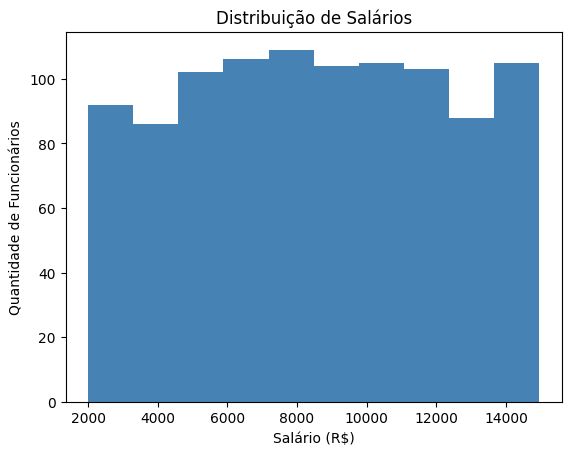

In [24]:
# Histograma mostra como os salários estão distribuídos
# bins=10 divide o intervalo em 10 faixas iguais
plt.hist(df["Salario"], bins=10, color="steelblue")
plt.title("Distribuição de Salários")
plt.xlabel("Salário (R$)")
plt.ylabel("Quantidade de Funcionários")
plt.show()

---
### O que este gráfico mostra?

Cada barra representa uma **faixa de salário** e sua altura indica **quantos funcionários** ganham dentro daquela faixa. O eixo X vai do menor ao maior salário; o eixo Y mostra a frequência (quantidade).

### Por que isso importa?

A distribuição salarial revela a **estrutura de remuneração** da empresa:

- Se as barras formam um "pico" no centro → a maioria ganha salários próximos (distribuição equilibrada)
- Se o pico está à esquerda e a cauda se estende para a direita → poucos funcionários ganham muito mais que a maioria (assimetria positiva)
- Picos muito estreitos podem indicar pouca variação salarial — o que pode significar falta de progressão de carreira

> Lembre-se: compare sempre a **média** com a **mediana** para entender se os altos salários estão distorcendo a percepção do salário típico.

## Célula 8 — Índices: o "endereço" de cada linha

Por padrão, o pandas numera cada linha: 0, 1, 2, 3... Esse número é o **índice** — pense nele como o número de um apartamento, um endereço único.

Com `set_index("ID_Funcionario")`, fazemos a coluna `ID_Funcionario` virar o novo índice. A partir daí, usamos `df_idx.loc[3]` para acessar diretamente o funcionário de ID 3 — muito mais intuitivo!

`reset_index()` desfaz isso e volta ao índice numérico padrão.

**Detalhe importante:** quando filtramos o DataFrame (`df[df["Status"] == "Ativo"]`), o índice **não é reiniciado**. Os números originais são mantidos — por isso o primeiro índice dos ativos pode ser 1, 2, 5... e não necessariamente 0.

In [25]:
# Índice padrão
print("Índice padrão:", df.index)

# set_index: ID_Funcionario vira o endereço
df_idx = df.set_index("ID_Funcionario")
print("\nFuncionário ID=3:")
print(df_idx.loc[3][["Nome", "Departamento", "Salario"]])

# reset_index: volta ao numérico
df_volta = df_idx.reset_index()
print(f"\nColunas após reset_index: {df_volta.columns.tolist()}")

# Índice após filtro — não começa em 0!
ativos = df[df["Status"] == "Ativo"]
print(f"\nPrimeiro índice dos Ativos : {ativos.index[0]}")
print(f"Total de Ativos            : {len(ativos)}")
print(f"Total de Inativos          : {len(df) - len(ativos)}")

Índice padrão: RangeIndex(start=0, stop=1000, step=1)

Funcionário ID=3:
Nome            Srta. Mariana Cunha
Departamento                     RH
Salario                    14027.93
Name: 3, dtype: object

Colunas após reset_index: ['ID_Funcionario', 'Nome', 'Departamento', 'Cargo', 'Salario', 'Data_Admissao', 'Genero', 'Idade', 'Estado_Civil', 'Status']

Primeiro índice dos Ativos : 2
Total de Ativos            : 515
Total de Inativos          : 485


## Célula 9 — Gráfico de barras: comparando categorias

O **gráfico de barras** é ideal para comparar quantidades entre categorias diferentes. Aqui queremos ver quantos funcionários são "Ativo" e quantos são "Inativo".

Seguimos o padrão: **calcular primeiro, plotar depois**.

1. `df["Status"].value_counts()` → conta quantas vezes cada valor aparece
2. `plt.bar(contagem.index, contagem.values)` → `index` = rótulos (x), `values` = quantidades (altura das barras)

Passamos uma lista de cores para diferenciar visualmente as categorias.

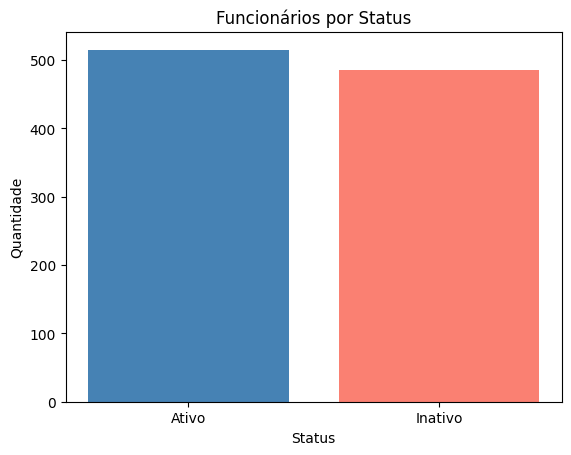

In [26]:
# Calculamos o que queremos mostrar
contagem = df["Status"].value_counts()

# Gráfico de barras: x = rótulos, height = valores
plt.bar(contagem.index, contagem.values, color=["steelblue", "salmon"])
plt.title("Funcionários por Status")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()

---
### O que este gráfico mostra?

A comparação direta entre o número de funcionários **Ativos** e **Inativos** na empresa. De relance, já conseguimos ver a proporção entre os dois grupos.

### Por que isso importa?

Esse é o **primeiro indicador de saúde do quadro de pessoal**:

- Uma proporção alta de inativos pode sinalizar alta rotatividade ou uma base histórica grande de desligamentos
- Acompanhar essa proporção ao longo do tempo revela tendências de crescimento ou enxugamento da equipe
- Para análises futuras, filtrar apenas os **ativos** garante que estamos trabalhando com dados do quadro atual

## Célula 10 — Tipo category: economizando memória e organizando dados

Por padrão, o pandas lê colunas de texto como tipo `object`. Para colunas que têm um conjunto **fixo e limitado** de valores (como departamentos, cargos, status...), o tipo `category` é mais eficiente.

**Por que usar `category`?**
- Economiza memória (internamente armazena um número no lugar do texto repetido)
- Permite ordenação personalizada
- Dá acesso ao acessor `.cat` com métodos específicos

O `for col in [lista]:` é um laço que percorre cada nome da lista e aplica a conversão automaticamente — evitamos repetir o mesmo código para cada coluna.

O `.cat.categories` lista todos os valores únicos em ordem alfabética.

In [27]:
# Converter colunas categóricas
for col in ["Departamento", "Cargo", "Genero", "Estado_Civil", "Status"]:
    df[col] = df[col].astype("category")

print("Tipos após conversão:")
print(df.dtypes)

print(f"\nDepartamentos: {df['Departamento'].cat.categories.tolist()}")
print(f"Cargos       : {df['Cargo'].cat.categories.tolist()}")

print("\nFuncionários por departamento:")
print(df["Departamento"].value_counts())

Tipos após conversão:
ID_Funcionario             int64
Nome                         str
Departamento            category
Cargo                   category
Salario                  float64
Data_Admissao     datetime64[us]
Genero                  category
Idade                      int64
Estado_Civil            category
Status                  category
dtype: object

Departamentos: ['Financeiro', 'Logística', 'Produção', 'RH', 'TI', 'Vendas']
Cargos       : ['Analista', 'Assistente', 'Coordenador', 'Gerente', 'Técnico']

Funcionários por departamento:
Departamento
Financeiro    189
Produção      182
RH            166
Vendas        160
Logística     156
TI            147
Name: count, dtype: int64


## Célula 11 — Barras horizontais: quando os rótulos são longos

`plt.barh()` (*bar horizontal*) funciona exatamente como `plt.bar()`, mas as barras ficam deitadas. Isso resolve um problema prático: quando os rótulos são nomes de departamentos ou categorias longas, no gráfico vertical eles ficam sobrepostos e ilegíveis.

Horizontal → rótulos no eixo Y → espaço de sobra para texto longo.

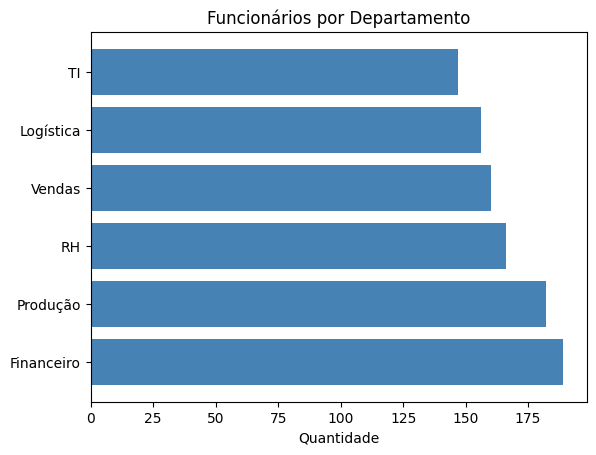

In [28]:
# Barras horizontais — melhor quando os rótulos são longos
dist = df["Departamento"].value_counts()

plt.barh(dist.index, dist.values, color="steelblue")
plt.title("Funcionários por Departamento")
plt.xlabel("Quantidade")
plt.show()

---
### O que este gráfico mostra?

A quantidade de funcionários em cada **departamento**, ordenada para facilitar a comparação. O departamento com a barra mais longa tem mais pessoas; o com a barra mais curta, menos.

### Por que isso importa?

Esse gráfico revela a **estrutura organizacional** da empresa:

- Departamentos muito maiores que os demais podem indicar o **core do negócio** (ex: Produção em uma indústria)
- Departamentos muito pequenos podem estar sobrecarregados ou subdimensionados
- Desequilíbrios grandes entre áreas são um ponto de atenção para gestores de RH na hora de planejar contratações e orçamento

## Célula 12 — `iloc`: seleção por posição numérica

`iloc` vem de **i**nteger **loc**ation — localização por número inteiro. Funciona como o índice de uma lista Python: baseado em posição, começando do zero.

| Exemplo | O que seleciona |
|---|---|
| `df.iloc[0]` | Primeira linha |
| `df.iloc[-1]` | Última linha |
| `df.iloc[2:5]` | Linhas 2, 3 e 4 (5 não entra) |
| `df.iloc[2:5, 1:4]` | Linhas 2-4 **e** colunas 1-3 |
| `df.iloc[[0, 99, 499]]` | Linhas em posições específicas |

> **`iloc` vs `loc`:** `iloc` usa posições (0, 1, 2...). `loc` usa rótulos (nome da coluna, valor do índice). Você vai ver `loc` na próxima célula.

In [29]:
# Uma linha → Series
print("Primeira linha (iloc[0]):")
print(df.iloc[0][["Nome", "Departamento", "Salario"]])

# Slice de linhas e colunas (posições 2,3,4 · colunas 1,2,3)
print("\niloc[2:5, 1:4]:")
print(df.iloc[2:5, 1:4].to_string())

# Última linha
print(f"\nÚltima linha — Nome: {df.iloc[-1]['Nome']}")

# Lista de posições específicas
amostra = df.iloc[[0, 99, 499, 999], [0, 1, 4]]
print("\nAmostra (posições 0, 99, 499, 999):")
print(amostra.to_string())

Primeira linha (iloc[0]):
Nome            Julia Nunes
Departamento      Logística
Salario             9088.34
Name: 0, dtype: object

iloc[2:5, 1:4]:
                  Nome Departamento        Cargo
2  Srta. Mariana Cunha           RH  Coordenador
3   Ana Sophia da Cruz     Produção      Técnico
4    Dr. Nicolas Pinto     Produção      Gerente

Última linha — Nome: Sra. Maysa Costela

Amostra (posições 0, 99, 499, 999):
     ID_Funcionario                Nome   Salario
0                 1         Julia Nunes   9088.34
99              100    Helena Gonçalves  13896.74
499             500     Nicolas Rezende   2799.98
999            1000  Sra. Maysa Costela  12549.72


## Célula 13 — Histograma de idades: praticando o conceito

Mesma lógica do histograma de salários — agora aplicada à coluna `Idade`.

Reparou como o padrão é idêntico? Isso é exatamente o que se espera: quando você entende o conceito, reutiliza para qualquer variável numérica sem esforço.

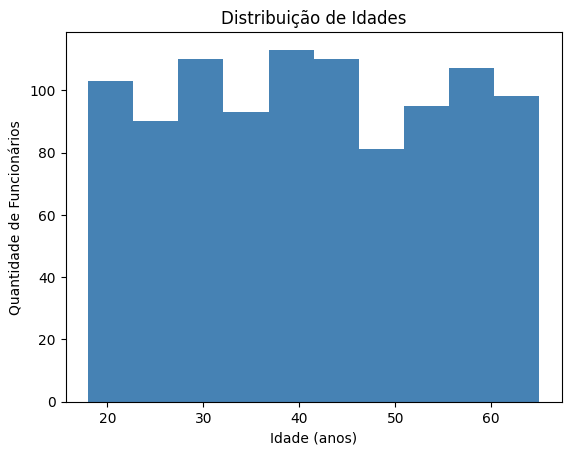

In [30]:
# Histograma de idades — bins=10 agrupa em ~5 anos por faixa
plt.hist(df["Idade"], bins=10, color="steelblue")
plt.title("Distribuição de Idades")
plt.xlabel("Idade (anos)")
plt.ylabel("Quantidade de Funcionários")
plt.show()

---
### O que este gráfico mostra?

A **distribuição das idades** dos funcionários. Cada barra agrupa aproximadamente 5 anos e mostra quantas pessoas estão naquela faixa etária.

### Por que isso importa?

A curva de idades é um dado estratégico para o RH:

- **Equipe jovem** (pico abaixo dos 30): alta energia, mas risco de rotatividade maior e curva de aprendizado
- **Equipe madura** (pico acima dos 45): experiência elevada, mas risco de aposentadorias próximas e perda de conhecimento institucional
- **Distribuição equilibrada**: o cenário mais saudável — mistura de experiência e renovação

> Empresas com muitos funcionários na mesma faixa etária tendem a enfrentar ondas de aposentadoria simultâneas — um risco para o planejamento de longo prazo.

## Célula 14 — `loc`: seleção por rótulo e filtros booleanos

`loc` vem de **label**-based **loc**ation — localização por rótulo. Com ele, filtramos usando **condições lógicas** em vez de posições.

**Sintaxe:**
```python
df.loc[condição_de_linha, ["col1", "col2"]]
```

O pandas avalia a condição para cada linha e retorna `True` ou `False`. Só as linhas `True` entram no resultado.

**Operadores para combinar condições:**
- `&` → E (as duas precisam ser verdadeiras)
- `|` → OU (pelo menos uma precisa ser verdadeira)
- `~` → NÃO (inverte o resultado)

> **Atenção:** coloque cada condição entre parênteses! Sem parênteses, o Python interpreta os operadores na ordem errada e você recebe um erro ou resultado incorreto.

Por fim, `df.loc[condição, "nova_coluna"] = "valor"` é a forma **segura e recomendada** de criar ou preencher novas colunas no pandas.

In [31]:
# 1. Por índice e nome de coluna
print("Linha 0, coluna Nome:", df.loc[0, "Nome"])

# 2. Condição booleana — cada condição entre parênteses!
producao = df.loc[
    df["Departamento"] == "Produção",
    ["Nome", "Cargo", "Salario"]
]
print(f"\nProdução: {len(producao)} funcionários (5 primeiros):")
print(producao.head(5).to_string(index=False))

# 3. Múltiplas condições: & = E, | = OU, ~ = NÃO
lideranca = df.loc[
    (df["Departamento"] == "Produção") &
    (df["Cargo"].isin(["Gerente", "Coordenador"])),
    ["Nome", "Cargo", "Salario", "Status"]
]
print(f"\nLiderança da Produção: {len(lideranca)}")
print(lideranca.to_string(index=False))

# 4. Atribuição segura — forma correta de criar colunas
df.loc[df["Salario"] >= 10000, "Faixa_Salarial"] = "Senior/Especialista"
df.loc[df["Salario"] <  10000, "Faixa_Salarial"] = "Pleno/Junior"
print("\nFaixa salarial:")
print(df["Faixa_Salarial"].value_counts())

Linha 0, coluna Nome: Julia Nunes

Produção: 182 funcionários (5 primeiros):
                 Nome   Cargo  Salario
   Ana Sophia da Cruz Técnico  6647.97
    Dr. Nicolas Pinto Gerente  8730.19
 João Miguel da Costa Técnico  4771.89
  Davi Lucca Teixeira Gerente 13512.53
Maria Julia das Neves Técnico 11440.30

Liderança da Produção: 83
                      Nome       Cargo  Salario  Status
         Dr. Nicolas Pinto     Gerente  8730.19 Inativo
       Davi Lucca Teixeira     Gerente 13512.53   Ativo
      Srta. Giovanna Pinto Coordenador  2503.83 Inativo
            Lorenzo Campos     Gerente 10022.05   Ativo
             Cauã Monteiro Coordenador  6495.75 Inativo
                Luna Silva Coordenador  3912.77 Inativo
               Isaac Lopes Coordenador  2297.43   Ativo
            Marina Ribeiro Coordenador  6106.47   Ativo
          Mirella da Costa     Gerente 14460.59   Ativo
         Anthony das Neves     Gerente 10523.68   Ativo
          Fernanda Almeida     Gerente 14948.1

## Célula 15 — `groupby`: calculando métricas por grupo

O `groupby` segue a lógica **"dividir → aplicar → combinar"**:

1. **Divide** o DataFrame em grupos (ex: um grupo por Cargo)
2. **Aplica** uma função em cada grupo (ex: `mean()`)
3. **Combina** os resultados em uma nova Series

```python
df.groupby("Cargo")["Salario"].mean()
```
Leitura: "para cada cargo, calcule a média salarial".

`.sort_values(ascending=False)` organiza do maior para o menor — essencial para gráficos de ranking onde queremos o maior valor em destaque.

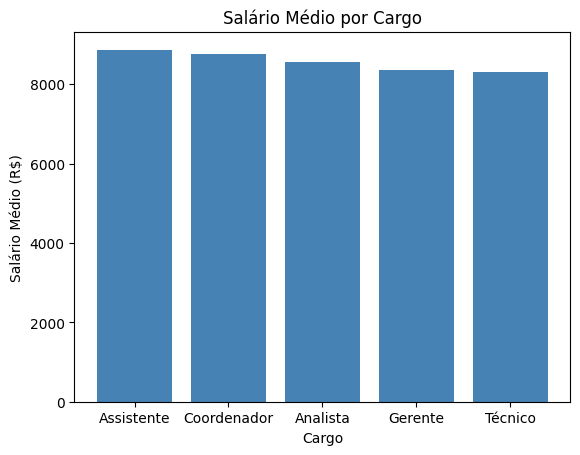

In [32]:
# Calculamos primeiro, plotamos depois
media_cargo = df.groupby("Cargo")["Salario"].mean().sort_values(ascending=False)

plt.bar(media_cargo.index, media_cargo.values, color="steelblue")
plt.title("Salário Médio por Cargo")
plt.xlabel("Cargo")
plt.ylabel("Salário Médio (R$)")
plt.show()

---
### O que este gráfico mostra?

O **salário médio de cada cargo**, ordenado do maior para o menor. Cada barra representa um cargo e sua extensão é o salário médio dos funcionários nele.

### Por que isso importa?

Esse gráfico permite identificar de imediato a **hierarquia salarial**:

- A diferença entre o cargo mais bem pago e o menos pago revela o **spread salarial** da empresa
- Cargos com salários médios próximos podem indicar que a progressão de carreira não está se refletindo adequadamente na remuneração
- É um ponto de partida para análises de **equidade salarial** — por exemplo, comparar a média de Gerentes de diferentes departamentos

## Célula 16 — Filtros expressivos: `query()`, `isin()` e `between()`

Além do `loc` com condições booleanas, o pandas oferece métodos mais legíveis para situações específicas:

**`query()`** — sintaxe parecida com SQL, fácil de ler em voz alta
```python
df.query("Salario > 8000 and Status == 'Ativo'")
```
Use `@variavel` para referenciar uma variável Python dentro da string.

**`isin(lista)`** — "está dentro desta lista de valores"
```python
df.loc[df["Cargo"].isin(["Gerente", "Coordenador"])]
# equivale a: Cargo == "Gerente" | Cargo == "Coordenador"
```

**`between(min, max)`** — filtra por intervalo fechado (inclui os extremos)
```python
df.loc[df["Idade"].between(30, 45)]
# equivale a: Idade >= 30 & Idade <= 45
```

Escolha o método que tornar seu código mais fácil de ler.

In [33]:
# 1. query() básico
resultado = df.query("Salario > 8000 and Status == 'Ativo'")
print(f"Ativos com salario > R$ 8.000: {len(resultado)}")

# 2. query() com variável externa — prefixo @
sal_min = 9000
deptos = ["Producao", "Logistica"]
res2 = df.query("Salario >= @sal_min and Departamento in @deptos")
print(f"\nProducao/Logistica >= R$ {sal_min:,}: {len(res2)}")

# 3. isin() — filtro por lista de valores
lideranca = df.loc[df["Cargo"].isin(["Gerente", "Coordenador"])]
print(f"\nTotal de lideres: {len(lideranca)}")
print(lideranca.groupby("Cargo")["Salario"].agg(["count", "mean"]).round(2))

# 4. between() — filtro por intervalo (extremos inclusos)
faixa = df.loc[df["Idade"].between(30, 45)]
print(f"\nFuncionarios 30-45 anos: {len(faixa)}")
print(f"Salario medio          : R$ {faixa['Salario'].mean():,.2f}")

Ativos com salario > R$ 8.000: 287

Producao/Logistica >= R$ 9,000: 0

Total de lideres: 446
             count     mean
Cargo                      
Coordenador    225  8763.86
Gerente        221  8363.46

Funcionarios 30-45 anos: 350
Salario medio          : R$ 8,817.64


## Célula 17 — Gráfico de pizza: partes de um todo

O gráfico de **pizza** é usado quando queremos mostrar como um total se divide em partes. Aqui: qual a proporção de cada estado civil?

`autopct="%1.1f%%"` adiciona automaticamente o percentual dentro de cada fatia, com 1 casa decimal (ex: `35.2%`).

> **Quando usar pizza?** Somente quando as fatias somam 100% e você quer enfatizar proporção relativa. Para comparar valores absolutos entre categorias, barras funcionam melhor.

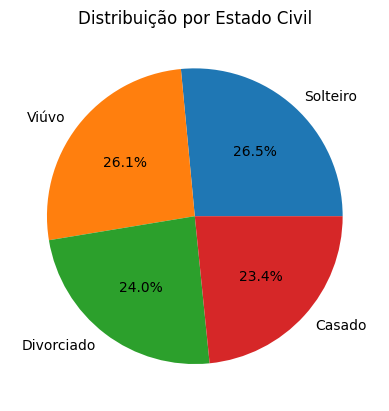

In [34]:
# Pizza funciona bem para "partes de um todo"
estado = df["Estado_Civil"].value_counts()

plt.pie(estado.values, labels=estado.index, autopct="%1.1f%%")
plt.title("Distribuição por Estado Civil")
plt.show()

---
### O que este gráfico mostra?

A **proporção de funcionários em cada estado civil** — qual fatia da torta corresponde a solteiros, casados, divorciados, etc.

### Por que isso importa?

Para o RH, o estado civil tem implicações práticas diretas:

- **Benefícios:** a proporção de casados e com dependentes impacta o custo e o design do plano de saúde e vale-alimentação
- **Engajamento:** programas de bem-estar (como suporte à família) são mais relevantes quando há muitos funcionários casados com filhos
- **Recrutamento:** entender o perfil demográfico ajuda a criar propostas de valor mais atrativas para o público-alvo

> Use pizza quando quiser mostrar **partes de um todo** — quando a soma das fatias precisa ser 100%.

## Célula 18 — Exercício prático: combinando múltiplos filtros

Agora colocamos em prática tudo que aprendemos sobre filtragem!

Este código usa `loc` com **três condições simultâneas** combinadas com `&` para encontrar exatamente o grupo desejado: líderes do departamento de TI que estão ativos.

Leia em voz alta:
> "Selecione as linhas onde Departamento é TI **E** Status é Ativo **E** Cargo está entre Gerente e Coordenador. Mostre Nome, Cargo, Salario e Data_Admissao."

`.sort_values("Salario", ascending=False)` ordena o resultado do maior para o menor salário.

In [35]:
lideranca_ti = df.loc[
    (df["Departamento"] == "TI") &
    (df["Status"] == "Ativo") &
    (df["Cargo"].isin(["Gerente", "Coordenador"])),
    ["Nome", "Cargo", "Salario", "Data_Admissao"]
].sort_values("Salario", ascending=False)

print(f"Lideres de TI ativos: {len(lideranca_ti)}")
print(lideranca_ti.to_string(index=False))

Lideres de TI ativos: 29
                       Nome       Cargo  Salario Data_Admissao
          Ana Clara Moreira     Gerente 14523.10    2025-01-06
               Mariane Melo Coordenador 14078.79    2022-08-03
             Felipe Moreira Coordenador 12777.68    2017-11-25
              Bryan da Cruz     Gerente 11790.21    2021-02-08
               Stella Costa     Gerente 11718.30    2023-05-09
               Calebe Alves Coordenador 11199.99    2018-11-12
  Gustavo Henrique Nogueira Coordenador 10803.29    2015-09-25
          Valentina Cardoso     Gerente 10602.13    2023-06-04
              Yuri Ferreira Coordenador 10328.64    2022-07-16
            Vicente Cardoso Coordenador  8991.42    2016-09-11
          Ana Júlia Cardoso     Gerente  8738.63    2021-05-30
               Alana da Luz Coordenador  7877.60    2020-03-22
  Srta. Maria Eduarda Souza Coordenador  7586.56    2018-02-17
       Dra. Ana Julia Rocha Coordenador  7556.46    2018-01-21
          Ana Clara Peixoto   

## Célula 19 — Faixas salariais detalhadas

Aqui refinamos a coluna `Faixa_Salarial` com **quatro níveis** em vez de dois. Usamos `loc` e `between()` para definir cada faixa.

A lógica: para cada linha onde o salário está dentro de um intervalo, atribuímos um rótulo. As condições precisam ser bem delimitadas para que cada funcionário caia em exatamente uma faixa.

In [36]:
df.loc[df["Salario"] >  12000, "Faixa_Salarial"] = "Especialista"
df.loc[df["Salario"].between(8001, 12000), "Faixa_Salarial"] = "Senior"
df.loc[df["Salario"].between(4001,  8000), "Faixa_Salarial"] = "Pleno"
df.loc[df["Salario"] <= 4000, "Faixa_Salarial"] = "Junior"

print(df["Faixa_Salarial"].value_counts())

Faixa_Salarial
Senior          328
Pleno           320
Especialista    220
Junior          132
Name: count, dtype: int64


## Célula 20 — Salário médio por departamento: groupby + visualização

Combinamos tudo que aprendemos em um único fluxo:

1. `groupby("Departamento")` → divide por departamento
2. `["Salario"].mean()` → calcula a média salarial de cada um
3. `.round(2)` → arredonda para 2 casas decimais
4. `.sort_values()` → ordena do menor para o maior (natural em barras horizontais, onde o maior fica no topo)
5. `plt.barh()` → visualiza o resultado

Repare no padrão que se repete em toda a aula: **calcular → guardar em variável → plotar**.

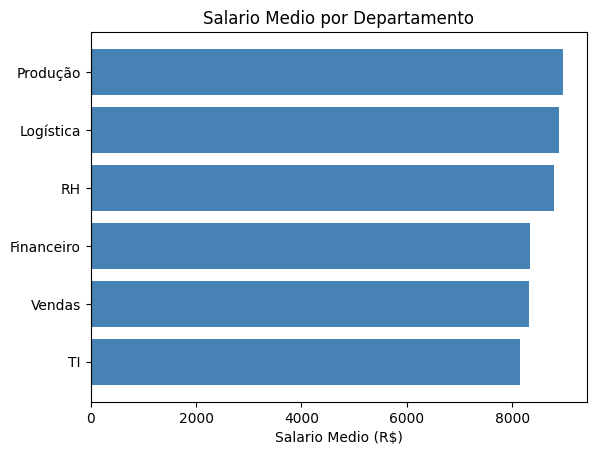

In [37]:
# Calcular primeiro
media_depto = (
    df.groupby("Departamento")["Salario"]
      .mean().round(2).sort_values()
)
# Plotar
plt.barh(media_depto.index, media_depto.values, color="steelblue")
plt.title("Salario Medio por Departamento")
plt.xlabel("Salario Medio (R$)")
plt.show()

---
### O que este gráfico mostra?

O **salário médio de cada departamento**, ordenado do menor para o maior. Quanto mais longa a barra, maior o salário médio daquele departamento.

### Por que isso importa?

Disparidades salariais entre departamentos são um dos dados mais estratégicos para gestão de pessoas:

- Departamentos com salário médio muito alto geralmente refletem **escassez de mercado** (ex: TI, Engenharia) ou maior complexidade técnica
- Grandes diferenças entre áreas podem gerar **insatisfação** e sentimento de injustiça entre equipes
- Esse gráfico é ponto de partida para análises de **equidade interna** — garantindo que a diferença salarial reflita competência e responsabilidade, não apenas o departamento ao qual a pessoa pertence

## Célula 21 — Pizza das faixas salariais: encerrando a aula

Para finalizar, visualizamos como os funcionários estão distribuídos entre as faixas salariais que criamos. Pizza faz sentido aqui porque queremos ver a **proporção** de cada nível dentro do total de funcionários.

---

Parabéns! Nesta aula você aprendeu a:

- Importar e carregar dados com pandas
- Explorar um DataFrame com os principais métodos (`head`, `info`, `describe`)
- Entender a diferença entre **Series** e **DataFrame**
- Selecionar dados por posição com **`iloc`** e por rótulo com **`loc`**
- Filtrar com condições booleanas, `query()`, `isin()` e `between()`
- Agrupar dados com **`groupby`**
- Criar **histogramas**, **gráficos de barras** e **pizza** com matplotlib

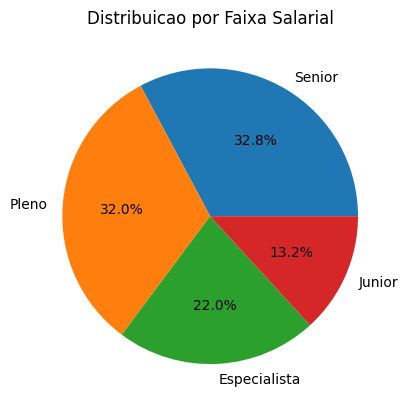

In [38]:
# Calcular primeiro
faixas = df["Faixa_Salarial"].value_counts()
# Plotar
plt.pie(faixas.values, labels=faixas.index, autopct="%1.1f%%")
plt.title("Distribuicao por Faixa Salarial")
plt.show()

---
### O que este gráfico mostra?

A **proporção de funcionários em cada faixa salarial** — Junior, Pleno, Sênior e Especialista — dentro do total da empresa.

### Por que isso importa?

Esse gráfico revela a **pirâmide de maturidade** da equipe:

- **Base larga de Juniors:** empresa em expansão ou com alta rotatividade na base — custo menor, mas maior necessidade de treinamento
- **Muitos Sêniors/Especialistas:** equipe experiente e autônoma, mas com folha de pagamento mais cara
- **Distribuição equilibrada:** combinação saudável de desenvolvimento e experiência

> Para a empresa, equilibrar essa pirâmide é fundamental: Juniors em excesso sobrecarregam os Sêniors com mentoria; Especialistas em excesso encarecem a operação.

---
**Fim da Aula 01.** Você acabou de analisar uma base de RH completa do zero — do carregamento até a visualização estratégica. Na próxima aula vamos aprofundar as visualizações e torná-las mais profissionais.

# Desafios

### Desafio 1

Encontre todos os funcionários que são Casados (usando a coluna Estado_Civil) E que ganham um Salario acima de R$ 9.000,00. Tente exibir na tela apenas as colunas "Nome", "Cargo" e "Salario" dessas pessoas.

In [39]:
funcionarios = df.loc[
    (df['Estado_Civil'] == 'Casado') &
    (df['Salario'] >= 9000)
]

funcionarios[['Nome', 'Cargo', 'Salario']]



,Nome,Cargo,Salario
14,Laura Rezende,Analista,11978.82
22,Maria Cecília Teixeira,Técnico,12411.29
33,Sr. Luigi Porto,Assistente,14387.97
36,Dra. Letícia Jesus,Assistente,13842.90
40,Sr. Bernardo da Cruz,Técnico,14074.49
...,...,...,...
967,Luana Barros,Técnico,9067.35
973,Sr. João Lucas Almeida,Analista,9268.53
977,Fernando Gonçalves,Gerente,13004.21
978,Dra. Pietra da Luz,Analista,9486.05
